In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
# 1. Load Dataset

df = pd.read_csv("/content/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [30]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [31]:
print("Dataset shape:", df.shape)
print("\nColumn data types:\n", df.dtypes)

Dataset shape: (1000, 8)

Column data types:
 gender                         object
race_ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object


In [32]:
# 2. Handle Missing Values

df = df.fillna(df.mean(numeric_only=True))

print("\nMissing values after handling:\n", df.isna().sum())


Missing values after handling:
 gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


In [33]:
# 3. Define Target

target_variable = "math_score"
print("\nTarget Variable:", target_variable)


Target Variable: math_score


In [34]:
# 4. Spliting
#X = df.drop([target_variable, "Student_ID"], axis=1)
X = df.drop(target_variable, axis=1)
y = df[target_variable]


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

In [35]:
# 5. Encoding

X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [36]:
import numpy as np

# 6. Scaling

X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_val = X_scaler.transform(X_val)
X_test = X_scaler.transform(X_test)


In [37]:
# 7. Convert to PyTorch Tensors

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train.values).view(-1, 1)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val.values).view(-1, 1)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test.values).view(-1, 1)

print("\nData preprocessing completed successfully")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


Data preprocessing completed successfully
X_train shape: torch.Size([600, 14])
y_train shape: torch.Size([600, 1])


In [38]:
input_size = X_train.shape[1]

model_1 = nn.Sequential(
    nn.Linear(input_size, 16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(8, 1)
)

print(model_1)

Sequential(
  (0): Linear(in_features=14, out_features=16, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=16, out_features=8, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=8, out_features=1, bias=True)
)


In [39]:
# Loss (Regression)
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model_1.parameters(), lr=0.01)

In [40]:
num_epochs = 150

train_losses = []
val_losses = []


for epoch in range(num_epochs):

    # Training

    model_1.train()

    outputs = model_1(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation

    model_1.eval()

    with torch.no_grad():
        val_outputs = model_1(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())

    # Print Progress

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {loss.item():.4f}, "
              f"Val Loss: {val_loss.item():.4f}")

Epoch [10/150], Train Loss: 4505.3945, Val Loss: 4431.4316
Epoch [20/150], Train Loss: 4102.9956, Val Loss: 4004.1721
Epoch [30/150], Train Loss: 3250.8093, Val Loss: 3074.1482
Epoch [40/150], Train Loss: 1882.1248, Val Loss: 1649.5291
Epoch [50/150], Train Loss: 1013.2715, Val Loss: 525.6869
Epoch [60/150], Train Loss: 776.9708, Val Loss: 210.4332
Epoch [70/150], Train Loss: 798.7115, Val Loss: 186.1736
Epoch [80/150], Train Loss: 685.6064, Val Loss: 220.1555
Epoch [90/150], Train Loss: 669.1428, Val Loss: 172.6148
Epoch [100/150], Train Loss: 634.3823, Val Loss: 131.4456
Epoch [110/150], Train Loss: 665.3542, Val Loss: 125.4173
Epoch [120/150], Train Loss: 663.4059, Val Loss: 138.7540
Epoch [130/150], Train Loss: 656.6987, Val Loss: 121.0646
Epoch [140/150], Train Loss: 650.7610, Val Loss: 117.2624
Epoch [150/150], Train Loss: 605.5974, Val Loss: 119.2321


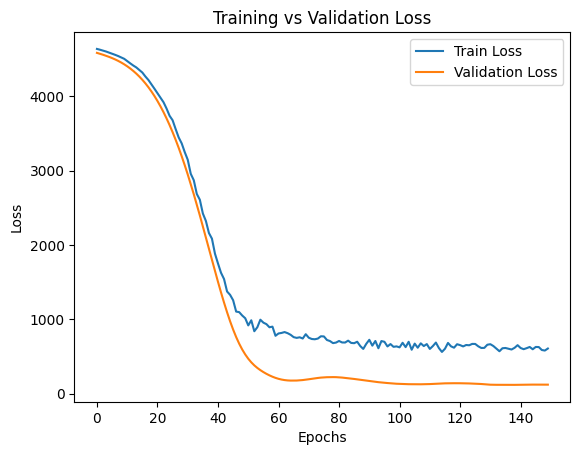

In [41]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluation on Test Set

model_1.eval()

with torch.no_grad():
    predictions = model_1(X_test)

    # Final Loss
    test_loss = criterion(predictions, y_test)

# Convert to numpy

y_pred = predictions.numpy()
y_true = y_test.numpy()

# MSE

mse1 = mean_squared_error(y_true, y_pred)
mae1 = mean_absolute_error(y_true, y_pred)
r21 = r2_score(y_true, y_pred)

print("Final Test Loss:", test_loss.item())
print("Mean Squared Error (MSE):", mse1)
print("Mean Absolute Error (MAE):", mae1)
print("R-squared (R2) Score:", r21)

Final Test Loss: 121.62643432617188
Mean Squared Error (MSE): 121.62642669677734
Mean Absolute Error (MAE): 9.2060546875
R-squared (R2) Score: 0.5001757740974426


In [43]:
input_size = X_train.shape[1]

model_2 = nn.Sequential(
    nn.Linear(input_size, 32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 1)
)

print(model_2)

Sequential(
  (0): Linear(in_features=14, out_features=32, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=32, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [44]:
# Loss (Regression)
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model_2.parameters(), lr=0.001)

In [45]:
num_epochs = 150
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # Training

    model_2.train()

    outputs = model_2(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation

    model_2.eval()

    with torch.no_grad():
        val_outputs = model_2(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())

    # Print Progress

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {loss.item():.4f}, "
              f"Val Loss: {val_loss.item():.4f}")

Epoch [10/150], Train Loss: 4614.6577, Val Loss: 4569.0562
Epoch [20/150], Train Loss: 4589.1064, Val Loss: 4541.9019
Epoch [30/150], Train Loss: 4551.2671, Val Loss: 4503.9575
Epoch [40/150], Train Loss: 4493.1152, Val Loss: 4449.1953
Epoch [50/150], Train Loss: 4418.6147, Val Loss: 4371.4199
Epoch [60/150], Train Loss: 4319.2827, Val Loss: 4264.6270
Epoch [70/150], Train Loss: 4179.9043, Val Loss: 4123.1567
Epoch [80/150], Train Loss: 3998.9622, Val Loss: 3942.3838
Epoch [90/150], Train Loss: 3761.2930, Val Loss: 3719.0063
Epoch [100/150], Train Loss: 3516.5767, Val Loss: 3451.4087
Epoch [110/150], Train Loss: 3150.1116, Val Loss: 3138.6909
Epoch [120/150], Train Loss: 2844.0505, Val Loss: 2784.0681
Epoch [130/150], Train Loss: 2464.4004, Val Loss: 2397.7251
Epoch [140/150], Train Loss: 2052.2678, Val Loss: 1995.0983
Epoch [150/150], Train Loss: 1609.8385, Val Loss: 1597.5542


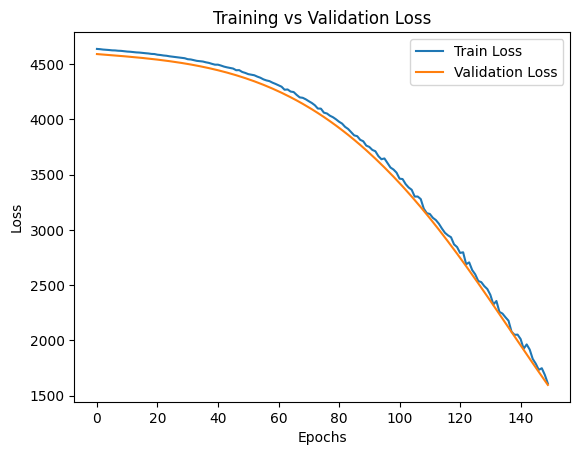

In [46]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluation on Test Set

model_2.eval()

with torch.no_grad():
    predictions = model_2(X_test)

    # Final Loss
    test_loss = criterion(predictions, y_test)

# Convert to numpy

y_pred = predictions.numpy()
y_true = y_test.numpy()

# MSE

mse2 = mean_squared_error(y_true, y_pred)
mae2 = mean_absolute_error(y_true, y_pred)
r22 = r2_score(y_true, y_pred)

print("Final Test Loss:", test_loss.item())
print("Mean Squared Error (MSE):", mse2)
print("Mean Absolute Error (MAE):", mae2)
print("R-squared (R2) Score:", r22)

Final Test Loss: 1512.3204345703125
Mean Squared Error (MSE): 1512.3204345703125
Mean Absolute Error (MAE): 36.908302307128906
R-squared (R2) Score: -5.21488618850708


In [48]:
input_size = X_train.shape[1]

model_3 = nn.Sequential(
    nn.Linear(input_size, 16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(8, 1)
)

print(model_3)

Sequential(
  (0): Linear(in_features=14, out_features=16, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=16, out_features=8, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=8, out_features=1, bias=True)
)


In [49]:
# Loss (Regression)
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model_3.parameters(), lr=0.001)

In [50]:
num_epochs = 150

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # Training

    model_3.train()

    outputs = model_3(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation

    model_3.eval()

    with torch.no_grad():
        val_outputs = model_3(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())

    # Print Progress

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {loss.item():.4f}, "
              f"Val Loss: {val_loss.item():.4f}")

Epoch [10/150], Train Loss: 4640.8823, Val Loss: 4598.9639
Epoch [20/150], Train Loss: 4631.0640, Val Loss: 4587.4902
Epoch [30/150], Train Loss: 4619.8618, Val Loss: 4575.2739
Epoch [40/150], Train Loss: 4604.9409, Val Loss: 4561.4858
Epoch [50/150], Train Loss: 4585.1265, Val Loss: 4545.5757
Epoch [60/150], Train Loss: 4575.1484, Val Loss: 4526.6094
Epoch [70/150], Train Loss: 4540.8350, Val Loss: 4503.9810
Epoch [80/150], Train Loss: 4517.4238, Val Loss: 4476.6719
Epoch [90/150], Train Loss: 4476.5132, Val Loss: 4443.4067
Epoch [100/150], Train Loss: 4428.5698, Val Loss: 4402.9224
Epoch [110/150], Train Loss: 4396.3477, Val Loss: 4354.1875
Epoch [120/150], Train Loss: 4318.6812, Val Loss: 4296.4043
Epoch [130/150], Train Loss: 4263.7456, Val Loss: 4228.8477
Epoch [140/150], Train Loss: 4176.6860, Val Loss: 4150.5220
Epoch [150/150], Train Loss: 4098.5840, Val Loss: 4060.8665


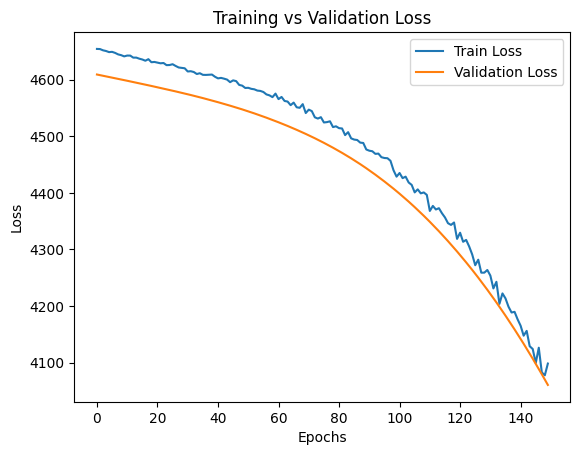

In [51]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluation on Test Set

model_3.eval()

with torch.no_grad():
    predictions = model_3(X_test)

    # Final Loss
    test_loss = criterion(predictions, y_test)

# Convert to numpy

y_pred = predictions.numpy()
y_true = y_test.numpy()

# MSE

mse3 = mean_squared_error(y_true, y_pred)
mae3 = mean_absolute_error(y_true, y_pred)
r23 = r2_score(y_true, y_pred)

print("Final Test Loss:", test_loss.item())
print("Mean Squared Error (MSE):", mse3)
print("Mean Absolute Error (MAE):", mae3)
print("R-squared (R2) Score:", r23)

Final Test Loss: 3887.2421875
Mean Squared Error (MSE): 3887.241943359375
Mean Absolute Error (MAE): 60.54658508300781
R-squared (R2) Score: -14.974634170532227


In [53]:
results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Activation": ["ReLU", "RuLU", "ReLU"],
    "Learning Rate": [0.01, 0.01, 0.001],
    "MSE": [mse1, mse2, mse3],
    "MAE": [mae1, mae2, mae3],
    "R2": [r21, r22, r23]
})

print(results)

     Model Activation  Learning Rate          MSE        MAE         R2
0  Model 1       ReLU          0.010   121.626427   9.206055   0.500176
1  Model 2       RuLU          0.010  1512.320435  36.908302  -5.214886
2  Model 3       ReLU          0.001  3887.241943  60.546585 -14.974634


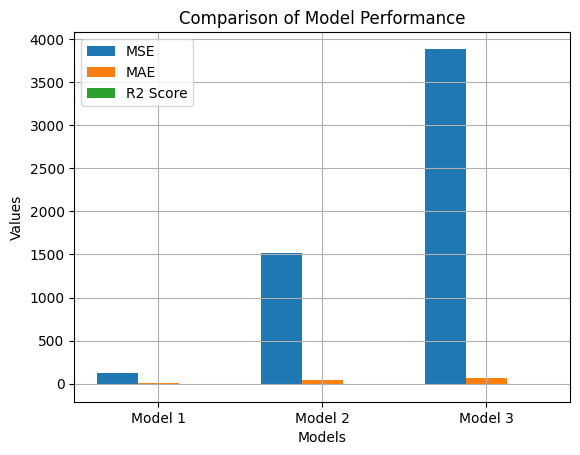

In [54]:
models = ["Model 1", "Model 2", "Model 3"]

x = np.arange(len(models))
width = 0.25



plt.bar(x - width, [mse1, mse2, mse3], width, label='MSE')
plt.bar(x, [mae1, mae2, mae3], width, label='MAE')
plt.bar(x + width, [r21, r22, r23], width, label='R2 Score')

plt.xlabel("Models")
plt.ylabel("Values")
plt.title("Comparison of Model Performance")
plt.xticks(x, models)

plt.legend()
plt.grid(True)
plt.show()